In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib
import warnings
import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import least_squares
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

No event loop hook running.


## 参数

这里按原 notebook 的短扫描=solvent、长扫描=sample 配对。更换数据时直接修改路径，代码不会根据数组长度猜测身份。
`ARTIFACT_POLARITY=+1` 表示用这组 solvent 可连续追踪的正峰作校准标记；它不是对任意溶剂都适用的物理定律。
更换溶剂、泵浦波长或测量条件后必须检查原始图和拟合图。

In [2]:
DATA_DIR = Path('.')
SOLVENT_CSV = DATA_DIR / 'd4e2225a-1508-4aab-8ca6-b12506a5a25b.csv'
SAMPLE_CSV = DATA_DIR / '3e8c0ce0-4b9e-4782-bc49-d55c96316f75.csv'
OUTPUT_DIR = DATA_DIR / 'ta_chirp_checked_outputs'

PUMP_EXCLUSION_BANDS_NM = []  # optional: [(low_nm, high_nm), ...]
SOLVENT_BASELINE_WINDOW_PS = (-7.1, -1.5)
SAMPLE_BASELINE_WINDOW_PS = (-2.8, -1.5)
ARTIFACT_FIT_WINDOW_PS = (-1.4, 1.7)
DISPLAY_TIME_WINDOW_PS = (-1.4, 1.7)
WAVELENGTH_BIN_SIZE = 3
ARTIFACT_POLARITY = +1
N_FIT_STARTS = 12

# The lower width is tied to solvent sampling, never to the sample time step.
SIGMA_MIN_IN_SOLVENT_STEPS = 0.55
SIGMA_UPPER_PS = 0.30
MIN_ARTIFACT_SNR = 5.0
MAX_FIT_RMSE_OVER_NOISE = 3.0
MAX_NEAR_OPTIMAL_PEAK_SPREAD_PS = 0.05
NEAR_OPTIMAL_COST_FRACTION = 0.05
MAX_MODEL_OVERSHOOT_RATIO = 3.0
CHIRP_POLYNOMIAL_DEGREE = 3
CHIRP_ROBUST_SCALE_PS = 0.025  # numerical robust-loss scale; not an error bar

TIME_REFERENCE = 'relative'  # 'relative' or 'absolute'
REFERENCE_WAVELENGTH_NM = 550.0
MANUAL_SOLVENT_SHIFT_PS = None  # delta: solvent labels t_r become t_r + delta

# Optional quantitative subtraction requires actual experimental metadata.
ENABLE_SOLVENT_SUBTRACTION = False
PUMP_ENERGY_SAMPLE = None
PUMP_ENERGY_SOLVENT = None
SAMPLE_OPTICAL_DENSITY = None
ATTENUATION_FACTOR_OVERRIDE = None
ARTIFACT_SUBTRACTION_WINDOW_PS = (-1.4, 1.7)
SHOW_DIAGNOSTIC_PLOTS = True

### 函数 A：各自读入、基线与分箱

波长轴只核对，不做光谱插值。每份数据的基线使用它自己的时间坐标。
噪声来自该 bin 的负时间实测点：`1.4826 × MAD`。比旧版增加了这份 solvent 的负时间点数，减少短窗口噪声估计的波动。
分箱只用于拟合，输出仍保留每个原始波长；不会跨越排除带或原始波长间隙。

In [3]:
@dataclass
class TAMatrix:
    wavelength_nm: np.ndarray
    time_ps: np.ndarray
    signal: np.ndarray
    source: Path


def window_mask(time, window, minimum=1, name="Window"):
    bounds = np.asarray(window, dtype=float)
    if bounds.shape != (2,) or not np.isfinite(bounds).all():
        raise ValueError(f"{name}: supply two finite time bounds.")
    lo, hi = np.sort(bounds)
    mask = (time >= lo) & (time <= hi)
    if int(mask.sum()) < minimum:
        raise ValueError(f"{name} {tuple(bounds)} has {mask.sum()} points; need at least {minimum}.")
    return mask


def load_ta_matrix(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path.resolve()}. Edit DATA_DIR and the CSV names.")
    raw = np.genfromtxt(path, delimiter=",", dtype=float)
    if raw.ndim != 2 or min(raw.shape) < 3:
        raise ValueError(f"{path.name}: expected a numeric TA matrix.")
    w, t, z = raw[1:, 0], raw[0, 1:], raw[1:, 1:]
    if not (np.isfinite(w).all() and np.isfinite(t).all() and np.isfinite(z).all()):
        raise ValueError(f"{path.name}: non-finite axes or signal values; inspect the CSV first.")
    wi, ti = np.argsort(w), np.argsort(t)
    w, t, z = w[wi], t[ti], z[np.ix_(wi, ti)]
    if np.any(np.diff(w) <= 0) or np.any(np.diff(t) <= 0):
        raise ValueError(f"{path.name}: duplicate wavelength/time coordinates are not supported.")
    return TAMatrix(w, t, z, path)


def keep_wavelengths(wavelength, bands):
    keep = np.ones(wavelength.size, dtype=bool)
    for lo, hi in bands:
        if lo is None and hi is None:
            continue
        if lo is None or hi is None or not np.isfinite([lo, hi]).all():
            raise ValueError("Each pump exclusion must have two finite bounds or two None values.")
        lo, hi = sorted((float(lo), float(hi)))
        keep &= ~((wavelength >= lo) & (wavelength <= hi))
    if not keep.any():
        raise ValueError("The exclusion bands removed every wavelength.")
    return keep


def robust_noise(traces, baseline_mask):
    baseline_values = traces[:, baseline_mask]
    centered = baseline_values - np.median(baseline_values, axis=1)[:, None]
    mad = 1.4826 * np.median(np.abs(centered), axis=1)
    positive = mad[mad > 0]
    floor = max(float(np.median(positive)) * 0.05 if positive.size else 0.0, 1e-12)
    return np.maximum(mad, floor)


def baseline_correct(signal, time, window):
    mask = window_mask(time, window, minimum=5, name="Baseline window")
    baseline = np.median(signal[:, mask], axis=1)
    corrected = signal - baseline[:, None]
    return corrected, baseline, robust_noise(corrected, mask), mask


def make_bins(wavelength, original_indices, typical_step, bin_size):
    if int(bin_size) != bin_size or bin_size < 1:
        raise ValueError("WAVELENGTH_BIN_SIZE must be a positive integer.")
    breaks = (np.diff(original_indices) > 1) | (np.diff(wavelength) > 3 * typical_step)
    segments = np.split(np.arange(wavelength.size), np.flatnonzero(breaks) + 1)
    return [segment[i:i + int(bin_size)] for segment in segments
            for i in range(0, len(segment), int(bin_size))]

### 函数 B：三瓣模型、明确的时间标记与稳健 chirp

令 $x=(t-mu)/sigma$，$G=e^{-x^2/2}$，模型为

$$R(t)=b_0+b_1(t-t_c)+a_0G+a_1xG+a_2(x^2-1)G.$$

新增项 $(x^2-1)G$ 与 Gaussian 二阶导数成比例，可以表示原模型遗漏的两侧负瓣。
这是受 [Lorenc et al. (2002)](https://doi.org/10.1007/s003400100750) 的 XPM 形状讨论启发的**经验模型**，不是逐字实现论文的有限 GVD 模型。

`mu` 与导数项系数可以互相补偿。因此这里把**去背景模型的指定极性主峰位置**定义为校准标记 $c_r(\lambda)$，记录 `gaussian_center_ps` 仅用于诊断。
主峰是操作性时间参考，不保证等于独立测得的脉冲交叉相关中心。不同峰型、Raman 贡献或跨波长改变极性时，需要重新确认标记。

对每个 bin 做多初值拟合，筛查噪声、残差、主峰位置多解、拟合区间边缘、系数边界和测量点间过冲。
接近宽度下界仅标记为时间采样限制；**不把亚步长拟合宽度当实验时间分辨率**。
最后仅用通过检查的主峰位置拟合一次稳健三次曲线。
多初值主峰跨度和多项式残差都不是统计置信区间。

In [4]:
def artifact_design(time, center_ps, sigma_ps, background_origin):
    """Background + G + xG + (x^2-1)G; coefficients absorb derivative units."""
    x = (np.asarray(time) - center_ps) / sigma_ps
    g = np.exp(-0.5 * x * x)
    return np.column_stack((np.ones_like(x), time - background_origin,
                            g, x * g, (x * x - 1) * g))


def pulse_extrema(parameters, limits, polarity=1):
    """Find continuous extrema analytically, without inventing a dense time grid."""
    ag, ad, ae, mu, log_sigma = parameters[2:]
    # d/dx [(ag + ad*x + ae*(x*x-1))*exp(-x*x/2)] = 0
    roots = np.roots(np.trim_zeros(np.array([-ae, -ad, 3*ae-ag, ad]), 'f'))
    real_roots = roots.real[np.abs(roots.imag) < 1e-7]
    candidate = np.r_[limits, mu + np.exp(log_sigma) * real_roots]
    candidate = np.sort(candidate[(candidate >= limits[0]) & (candidate <= limits[1])])
    x = (candidate - mu) / np.exp(log_sigma)
    values = (ag + ad*x + ae*(x*x-1)) * np.exp(-0.5*x*x)
    best = int(np.argmax(polarity * values))
    return float(candidate[best]), float(polarity*values[best]), float(np.max(abs(values)))


def fit_artifact_multistart(time, trace, noise, fit_window, n_starts=12,
                           near_cost_fraction=0.05, polarity=1):
    mask = window_mask(time, fit_window, minimum=12, name='Artifact fit window')
    t, observed = np.asarray(time[mask]), np.asarray(trace[mask])
    origin = float(np.mean(t))
    dt = float(np.median(np.diff(t)))
    sigma_lo, sigma_hi = SIGMA_MIN_IN_SOLVENT_STEPS * dt, SIGMA_UPPER_PS
    if not 0 < sigma_lo < sigma_hi or polarity not in (-1, 1):
        raise ValueError('Check sigma bounds and ARTIFACT_POLARITY (+1 or -1).')
    if int(n_starts) != n_starts or n_starts < 2:
        raise ValueError('N_FIT_STARTS must be an integer >= 2.')
    if not np.isfinite(near_cost_fraction) or near_cost_fraction < 0:
        raise ValueError('NEAR_OPTIMAL_COST_FRACTION must be finite and nonnegative.')
    noise = max(float(noise), 1e-12)
    observed_amplitude = max(float(np.max(abs(observed-np.median(observed)))), noise)
    # Numerical scaling, not a measurement uncertainty or confidence interval.
    numerical_scale = max(noise, observed_amplitude/20)
    y = observed / numerical_scale
    coefficient_limit = 4 * max(float(np.ptp(y)), 1.0)
    lower = np.r_[[-np.inf, -np.inf], [-coefficient_limit]*3,
                  t[0]+dt, np.log(sigma_lo)]
    upper = np.r_[[np.inf, np.inf], [coefficient_limit]*3,
                  t[-1]-dt, np.log(sigma_hi)]

    def residual(p):
        return artifact_design(t, p[5], np.exp(p[6]), origin) @ p[:5] - y

    def jacobian(p):
        ag, ad, ae, mu, log_sigma = p[2:]
        sigma = np.exp(log_sigma)
        x = (t-mu)/sigma
        g = np.exp(-0.5*x*x)
        return np.column_stack((
            artifact_design(t, mu, sigma, origin),
            (ag*x + ad*(x*x-1) + ae*(x**3-3*x))*g/sigma,
            (ag*x*x + ad*(x**3-x) + ae*(x**4-3*x*x))*g))

    candidates = []
    for mu in np.arange(lower[5]+1e-9, upper[5]-1e-9, dt/2):
        for sigma in np.geomspace(sigma_lo*1.05, sigma_hi*0.95, 5):
            design = artifact_design(t, mu, sigma, origin)
            linear = np.linalg.lstsq(design, y, rcond=None)[0]
            p = np.clip(np.r_[linear, mu, np.log(sigma)], lower+1e-9, upper-1e-9)
            r = residual(p)
            candidates.append((float(4*np.sum(np.sqrt(1+(r/2)**2)-1)), p))
    starts = []
    for _, p in sorted(candidates, key=lambda item: item[0]):
        if any(abs(p[5]-q[5]) < 0.75*dt and abs(p[6]-q[6]) < 0.45 for q in starts):
            continue
        starts.append(p)
        if len(starts) == int(n_starts):
            break
    solutions = []
    for start in starts:
        result = least_squares(residual, start, jac=jacobian, bounds=(lower, upper),
                               loss='soft_l1', f_scale=2.0, x_scale='jac', max_nfev=500)
        if result.success and np.isfinite(result.x).all():
            peak, height, absolute_max = pulse_extrema(result.x, (t[0], t[-1]), polarity)
            solutions.append((result, peak, height, absolute_max))
    if not solutions:
        return dict(success=False, peak_time_ps=np.nan, gaussian_center_ps=np.nan,
                    sigma_ps=np.nan, peak_spread_ps=np.inf, snr=0.0,
                    rmse_over_noise=np.inf, rmse=np.inf, overshoot_ratio=np.inf,
                    near_time_bound=True, near_width_bound=True, coefficient_bound=True,
                    n_successful=0, n_near=0, parameters=None,
                    t=t, observed=observed, origin=origin, dt=dt)
    best, peak, height, absolute_max = min(solutions, key=lambda v: v[0].cost)
    near = [v for v in solutions if v[0].cost <= best.cost*(1+near_cost_fraction)+1e-10]
    peak_spread = float(np.ptp([v[1] for v in near])) if len(solutions) >= 2 else np.inf
    p = best.x.copy()
    p[:5] *= numerical_scale
    predicted = artifact_design(t, p[5], np.exp(p[6]), origin) @ p[:5]
    rmse = float(np.sqrt(np.mean((predicted-observed)**2)))
    sigma = float(np.exp(p[6]))
    sampled_pulse = artifact_design(t, p[5], sigma, origin)[:, 2:] @ p[2:5]
    # Use measured-time support for SNR, not the potentially unmeasured peak height.
    snr = float(np.max(polarity*sampled_pulse)/noise)
    return dict(success=True, peak_time_ps=peak, gaussian_center_ps=float(p[5]),
                sigma_ps=sigma, peak_spread_ps=peak_spread, snr=snr,
                rmse_over_noise=rmse/noise, rmse=rmse,
                overshoot_ratio=absolute_max*numerical_scale/observed_amplitude,
                near_time_bound=bool(peak <= t[0]+dt or peak >= t[-1]-dt),
                near_width_bound=bool(sigma <= sigma_lo*1.08 or sigma >= sigma_hi*0.92),
                coefficient_bound=bool(np.any(abs(best.x[2:5]) >= 0.98*coefficient_limit)),
                n_successful=len(solutions), n_near=len(near),
                parameters=p, predicted=predicted, t=t, observed=observed,
                origin=origin, dt=dt)


def robust_chirp_fit(wavelength, peak_time, use, degree):
    use = np.asarray(use, dtype=bool)
    if int(degree) != degree or degree < 1 or use.sum() < degree+3:
        raise ValueError('Too few accepted anchors for this polynomial degree.')
    w, y = np.asarray(wavelength)[use], np.asarray(peak_time)[use]
    center, scale = float((w.min()+w.max())/2), float(np.ptp(w)/2)
    if scale <= 0:
        raise ValueError('Anchors must span multiple wavelengths.')
    design = np.vander((w-center)/scale, degree+1, increasing=True)
    initial = np.linalg.lstsq(design, y, rcond=None)[0]
    fit = least_squares(lambda p: design@p-y, initial, loss='soft_l1',
                        f_scale=CHIRP_ROBUST_SCALE_PS)
    if not fit.success:
        raise RuntimeError('Smooth chirp fit did not converge.')
    residual = y-design@fit.x
    return dict(coefficients=fit.x, center_nm=center, scale_nm=scale, degree=int(degree),
                anchor_min_nm=float(w.min()), anchor_max_nm=float(w.max()),
                residual_mad_ps=float(1.4826*np.median(abs(residual-np.median(residual)))),
                median_abs_residual_ps=float(np.median(abs(residual))),
                max_anchor_gap_nm=float(np.max(np.diff(w))))


def evaluate_chirp(model, wavelength):
    x = (np.atleast_1d(wavelength)-model['center_nm'])/model['scale_nm']
    return np.polynomial.polynomial.polyval(x, model['coefficients'])

### 函数 C：保留各自时间轴的校正

令 $D(\lambda)$ 为需要消除的波长间延迟：

$$S_{\mathrm{out}}(\lambda,u)=\operatorname{interp}[t_s,S(\lambda,t_s)]\big(u+D(\lambda)\big).$$

相对模式：$D(\lambda)=c_r(\lambda)-c_r(\lambda_{ref})$，所以参考波长 $D=0$。
绝对模式：$D(\lambda)=c_r(\lambda)+\delta$，需要实验确认的整体偏移 $\delta$。

可选扣除时，solvent 必须在自己的原始时间轴查询 $u+D(\lambda)-\delta$。
**不能按 sample/solvent 的列序号相减。** 范围外不外推、不补零；输出缺失值保留 NaN。

In [5]:
def correct_time(source_time, signal, output_time, delay_curve):
    source_time = np.asarray(source_time, dtype=float)
    output_time = np.asarray(output_time, dtype=float)
    delay_curve = np.asarray(delay_curve, dtype=float)
    signal = np.asarray(signal, dtype=float)
    if signal.shape != (delay_curve.size, source_time.size):
        raise ValueError('Signal shape must be (wavelength, source time).')
    if not np.isfinite(source_time).all() or np.any(np.diff(source_time) <= 0):
        raise ValueError('Source time must be finite and strictly increasing.')
    if not np.isfinite(output_time).all() or not np.isfinite(delay_curve).all():
        raise ValueError('Output time and delay curve must be finite.')
    return np.vstack([np.interp(output_time+shift, source_time, trace,
                                left=np.nan, right=np.nan)
                      for shift, trace in zip(delay_curve, signal)])


def attenuation_factor(od, override):
    if override is not None:
        if not np.isfinite(override) or not 0 < override <= 1:
            raise ValueError('Attenuation override must be in (0, 1].')
        return float(override), 'provided attenuation factor'
    if od is None or not np.isfinite(od) or od < 0:
        raise ValueError('Supply OD at the pump wavelength, or an attenuation override.')
    x = float(od)*np.log(10.)
    return float(-np.expm1(-x)/x if x > 1e-10 else 1-x/2), 'Lorenc Eq. 17'


def matrix_for_csv(time, wavelength, signal):
    matrix = np.empty((len(wavelength)+1, len(time)+1), dtype=float)
    matrix[0, 0] = 0.
    matrix[0, 1:] = time
    matrix[1:, 0] = wavelength
    matrix[1:, 1:] = signal
    return matrix


def export_matrix(filename, time, signal):
    np.savetxt(OUTPUT_DIR/filename, matrix_for_csv(time, wavelength_nm, signal),
               delimiter=',', fmt='%.17g')  # preserve float64 axis values on round-trip

## 1. 读入、核对相同波长与不同时间轴

In [6]:
solvent_raw = load_ta_matrix(SOLVENT_CSV)
sample_raw = load_ta_matrix(SAMPLE_CSV)
if not np.array_equal(solvent_raw.wavelength_nm, sample_raw.wavelength_nm):
    raise ValueError('The wavelength arrays must match exactly; no spectral resampling is performed.')
keep = keep_wavelengths(solvent_raw.wavelength_nm, PUMP_EXCLUSION_BANDS_NM)
wavelength_nm = solvent_raw.wavelength_nm[keep]
original_indices = np.flatnonzero(keep)
solvent_signal = solvent_raw.signal[keep]
sample_signal = sample_raw.signal[keep]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame([
    dict(measurement=label, wavelengths=len(wavelength_nm), time_points=len(raw.time_ps),
         time_min_ps=raw.time_ps[0], time_max_ps=raw.time_ps[-1],
         fit_window_step_ps=np.median(np.diff(raw.time_ps[window_mask(raw.time_ps, ARTIFACT_FIT_WINDOW_PS)])))
    for label, raw in [('solvent', solvent_raw), ('sample', sample_raw)]
]))
print('Wavelength arrays match exactly. Sample and solvent retain separate time arrays.')

Wavelength arrays match exactly. Sample and solvent retain separate time arrays.


,measurement,wavelengths,time_points,time_min_ps,time_max_ps,fit_window_step_ps
0,solvent,489,101,-7.001139,2.998861,0.100098
1,sample,489,337,-2.707672,7549.501479,0.200602


## 2. 各自基线校正；仅为拟合建立 solvent 波长 bin

In [7]:
solvent_bc, solvent_baseline, solvent_noise, solvent_baseline_mask = baseline_correct(
    solvent_signal, solvent_raw.time_ps, SOLVENT_BASELINE_WINDOW_PS)
sample_bc, sample_baseline, sample_noise, sample_baseline_mask = baseline_correct(
    sample_signal, sample_raw.time_ps, SAMPLE_BASELINE_WINDOW_PS)
bin_members = make_bins(wavelength_nm, original_indices,
                       float(np.median(np.diff(solvent_raw.wavelength_nm))), WAVELENGTH_BIN_SIZE)
bin_wavelength_nm = np.array([np.mean(wavelength_nm[g]) for g in bin_members])
solvent_bin_traces = np.vstack([np.median(solvent_bc[g], axis=0) for g in bin_members])
bin_solvent_noise = robust_noise(solvent_bin_traces, solvent_baseline_mask)
print(f'Bins: {len(bin_members)}; baseline points: solvent={solvent_baseline_mask.sum()}, sample={sample_baseline_mask.sum()}')

Bins: 163; baseline points: solvent=55, sample=7


## 3. 只拟合 solvent，并显示明确的排除原因

In [8]:
fit_details, rows = [], []
for i, (wave, trace, noise) in enumerate(zip(bin_wavelength_nm, solvent_bin_traces, bin_solvent_noise)):
    fit = fit_artifact_multistart(solvent_raw.time_ps, trace, noise, ARTIFACT_FIT_WINDOW_PS,
                                  N_FIT_STARTS, NEAR_OPTIMAL_COST_FRACTION, ARTIFACT_POLARITY)
    fit_details.append(fit)
    reasons = []
    if not fit['success']: reasons.append('fit_failed')
    if fit['snr'] < MIN_ARTIFACT_SNR: reasons.append('low_snr')
    if fit['rmse_over_noise'] > MAX_FIT_RMSE_OVER_NOISE: reasons.append('large_residual')
    if fit['peak_spread_ps'] > MAX_NEAR_OPTIMAL_PEAK_SPREAD_PS: reasons.append('ambiguous_peak_time')
    if fit['overshoot_ratio'] > MAX_MODEL_OVERSHOOT_RATIO: reasons.append('between_point_overshoot')
    if fit['near_time_bound']: reasons.append('peak_at_window_edge')
    if fit['coefficient_bound']: reasons.append('coefficient_bound')
    if fit['sigma_ps'] >= SIGMA_UPPER_PS*0.92: reasons.append('width_upper_bound')
    rows.append(dict(bin_index=i, wavelength_nm=wave, n_pixels=len(bin_members[i]),
                     peak_time_ps=fit['peak_time_ps'], gaussian_center_ps=fit['gaussian_center_ps'],
                     sigma_ps=fit['sigma_ps'], width_at_sampling_or_search_bound=fit['near_width_bound'],
                     peak_multistart_spread_ps=fit['peak_spread_ps'], snr=fit['snr'],
                     rmse=fit['rmse'], rmse_over_noise=fit['rmse_over_noise'],
                     overshoot_ratio=fit['overshoot_ratio'], baseline_noise=noise,
                     successful_starts=fit['n_successful'], near_optimal_starts=fit['n_near'],
                     fit_accepted=not reasons, rejection_reason=';'.join(reasons)))
    if (i+1) % 40 == 0 or i+1 == len(bin_members):
        print(f'Fitted {i+1}/{len(bin_members)} bins', flush=True)
bin_diagnostics = pd.DataFrame(rows)
fit_accepted = bin_diagnostics.fit_accepted.to_numpy(bool)
display(bin_diagnostics[['fit_accepted', 'rejection_reason']].value_counts().rename('bins').reset_index())
print(f'Accepted peak anchors: {fit_accepted.sum()}/{len(fit_accepted)}')

Fitted 40/163 bins
Fitted 80/163 bins
Fitted 120/163 bins
Fitted 160/163 bins
Fitted 163/163 bins
Accepted peak anchors: 106/163


,fit_accepted,rejection_reason,bins
0,True,,106
1,False,low_snr,34
2,False,low_snr;ambiguous_peak_time,15
3,False,between_point_overshoot,3
4,False,ambiguous_peak_time,2
5,False,low_snr;peak_at_window_edge,2
6,False,low_snr;between_point_overshoot,1


## 4. 稳健 chirp 曲线与独立的整体时间参考

In [9]:
chirp_model = robust_chirp_fit(bin_wavelength_nm, bin_diagnostics.peak_time_ps.to_numpy(),
                               fit_accepted, CHIRP_POLYNOMIAL_DEGREE)
raw_chirp_curve_ps = evaluate_chirp(chirp_model, wavelength_nm)
reference_index = int(np.argmin(abs(wavelength_nm-REFERENCE_WAVELENGTH_NM)))
reference_wavelength_nm = float(wavelength_nm[reference_index])
reference_solvent_peak_ps = float(raw_chirp_curve_ps[reference_index])
if MANUAL_SOLVENT_SHIFT_PS is not None and not np.isfinite(MANUAL_SOLVENT_SHIFT_PS):
    raise ValueError('MANUAL_SOLVENT_SHIFT_PS must be finite or None.')
if TIME_REFERENCE == 'relative':
    applied_delay_curve_ps = raw_chirp_curve_ps-reference_solvent_peak_ps
    global_offset_applied_to_sample_ps = 0.0
elif TIME_REFERENCE == 'absolute':
    if MANUAL_SOLVENT_SHIFT_PS is None:
        raise ValueError('Absolute mode requires an experimentally established solvent-to-sample shift.')
    applied_delay_curve_ps = raw_chirp_curve_ps+MANUAL_SOLVENT_SHIFT_PS
    global_offset_applied_to_sample_ps = reference_solvent_peak_ps+MANUAL_SOLVENT_SHIFT_PS
else:
    raise ValueError("TIME_REFERENCE must be 'relative' or 'absolute'.")
anchor_wavelengths = bin_wavelength_nm[fit_accepted]
chirp_extrapolated = (wavelength_nm < anchor_wavelengths.min()) | (wavelength_nm > anchor_wavelengths.max())
nearest_anchor_distance_nm = np.min(abs(wavelength_nm[:, None]-anchor_wavelengths[None, :]), axis=1)
bin_diagnostics['curve_residual_ps'] = bin_diagnostics.peak_time_ps-evaluate_chirp(chirp_model, bin_wavelength_nm)
display(pd.Series(dict(
    mode=TIME_REFERENCE, reference_wavelength_nm=reference_wavelength_nm,
    reference_solvent_peak_ps=reference_solvent_peak_ps,
    applied_delay_min_ps=float(applied_delay_curve_ps.min()),
    applied_delay_max_ps=float(applied_delay_curve_ps.max()),
    automatic_sample_alignment=False,
    supplied_solvent_to_sample_shift_ps=MANUAL_SOLVENT_SHIFT_PS,
    median_anchor_residual_ps=chirp_model['median_abs_residual_ps'],
    largest_anchor_gap_nm=chirp_model['max_anchor_gap_nm'],
    max_distance_to_anchor_nm=float(nearest_anchor_distance_nm.max()),
    extrapolated_edge_wavelengths=int(chirp_extrapolated.sum()),
), name='value').to_frame())
if chirp_model['max_anchor_gap_nm'] > 40:
    print('Caution: part of the spectral range has sparse reliable anchors; inspect the curve and distance flags.')

Caution: part of the spectral range has sparse reliable anchors; inspect the curve and distance flags.


,value
mode,relative
reference_wavelength_nm,550.126343
reference_solvent_peak_ps,0.039391
applied_delay_min_ps,-0.559513
applied_delay_max_ps,0.346706
automatic_sample_alignment,False
supplied_solvent_to_sample_shift_ps,None
median_anchor_residual_ps,0.012099
largest_anchor_gap_nm,60.994283
max_distance_to_anchor_nm,30.44281


## 5. 应用到 sample 自己的时间网格

同时保留完整时间网格的输出，以及只取所有波长都有测量支持的时间列、无边缘 NaN 的输出。
后者是前者的裁剪版，不是补零或外推版。solvent 的诊断输出仍用它自己的 101 点网格（以本示例为例）。

In [10]:
corrected_time_ps = sample_raw.time_ps.copy()
sample_chirp_corrected = correct_time(sample_raw.time_ps, sample_bc,
                                      corrected_time_ps, applied_delay_curve_ps)
# This view uses the solvent's own time origin; it is not an alignment to sample.
solvent_own_delay_curve_ps = raw_chirp_curve_ps-reference_solvent_peak_ps
solvent_chirp_corrected = correct_time(solvent_raw.time_ps, solvent_bc,
                                       solvent_raw.time_ps, solvent_own_delay_curve_ps)
common_support = np.isfinite(sample_chirp_corrected).all(axis=0)
if not common_support.any():
    raise ValueError('No common measured support remains after correction.')
print(f'Sample output: {sample_chirp_corrected.shape}; full original time grid retained.')
print(f'Common-support output: {common_support.sum()} of {corrected_time_ps.size} time columns.')
if TIME_REFERENCE == 'relative':
    assert applied_delay_curve_ps[reference_index] == 0.0
    np.testing.assert_array_equal(sample_chirp_corrected[reference_index], sample_bc[reference_index])
    print('Reference-wavelength trace retains its original time position exactly (after baseline removal).')
np.testing.assert_array_equal(corrected_time_ps, sample_raw.time_ps)

Sample output: (489, 337); full original time grid retained.
Common-support output: 333 of 337 time columns.
Reference-wavelength trace retains its original time position exactly (after baseline removal).


### 可选：按论文 Eq. 16–17 做 solvent 振幅扣除

$$S_c=S-S_r\,(E_s/E_r)f,\qquad f=(1-10^{-OD})/(\ln(10)\,OD).$$

这一步与 chirp 校正不同。当前文件没有提供实验确认的整体偏移、泵浦能量和 OD，所以默认关闭。
填写这些值并启用后，代码会在各自原始时间坐标上对齐，再扣除；不会自动拿 `f=1` 当定量结果。

In [11]:
artifact_corrected_sample = None
subtraction_scale = None
subtraction_support = None
if ENABLE_SOLVENT_SUBTRACTION:
    if MANUAL_SOLVENT_SHIFT_PS is None:
        raise ValueError('Solvent subtraction requires the measured solvent-to-sample time shift.')
    if any(v is None or not np.isfinite(v) or v <= 0
           for v in [PUMP_ENERGY_SAMPLE, PUMP_ENERGY_SOLVENT]):
        raise ValueError('Supply both experimental pump energies in the same units.')
    f_attenuation, attenuation_source = attenuation_factor(SAMPLE_OPTICAL_DENSITY,
                                                          ATTENUATION_FACTOR_OVERRIDE)
    subtraction_scale = PUMP_ENERGY_SAMPLE/PUMP_ENERGY_SOLVENT*f_attenuation
    aligned_solvent = correct_time(solvent_raw.time_ps, solvent_bc, corrected_time_ps,
                                   applied_delay_curve_ps-MANUAL_SOLVENT_SHIFT_PS)
    active = window_mask(corrected_time_ps, ARTIFACT_SUBTRACTION_WINDOW_PS)
    scaled_solvent_term = np.zeros_like(sample_chirp_corrected)
    scaled_solvent_term[:, active] = subtraction_scale*aligned_solvent[:, active]
    artifact_corrected_sample = sample_chirp_corrected-scaled_solvent_term
    subtraction_support = active[None, :] & np.isfinite(aligned_solvent) & np.isfinite(sample_chirp_corrected)
    print(f'Solvent subtraction enabled. Scale={subtraction_scale:.6g}; {attenuation_source}.')
else:
    print('Chirp correction completed. Solvent amplitude subtraction was not requested in the parameters.')

Chirp correction completed. Solvent amplitude subtraction was not requested in the parameters.


## 6. 必看图：原始点、连续拟合、chirp 与校正前后

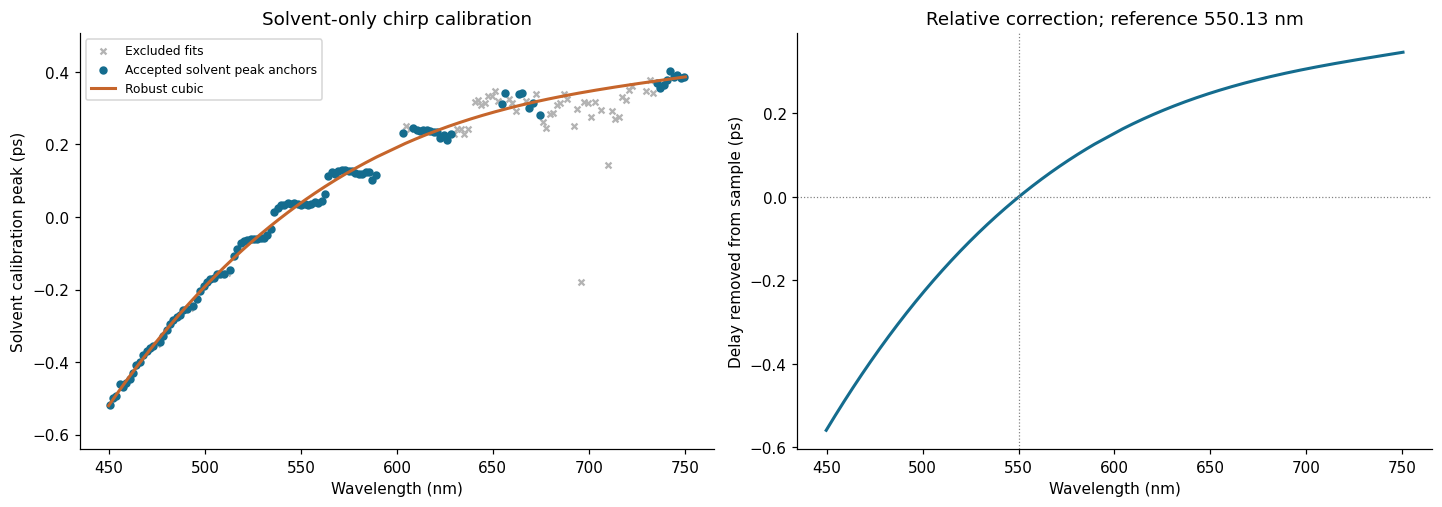

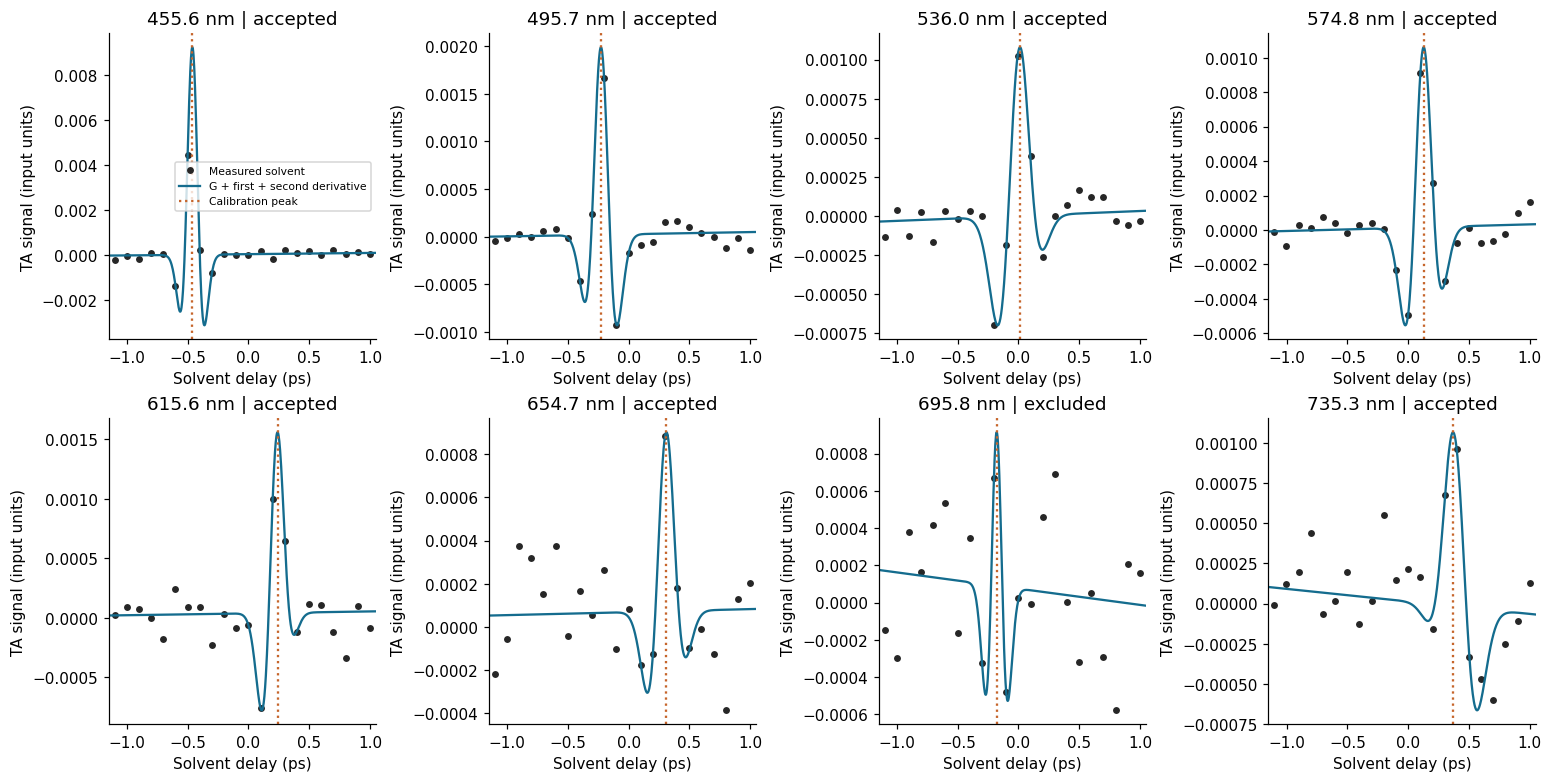

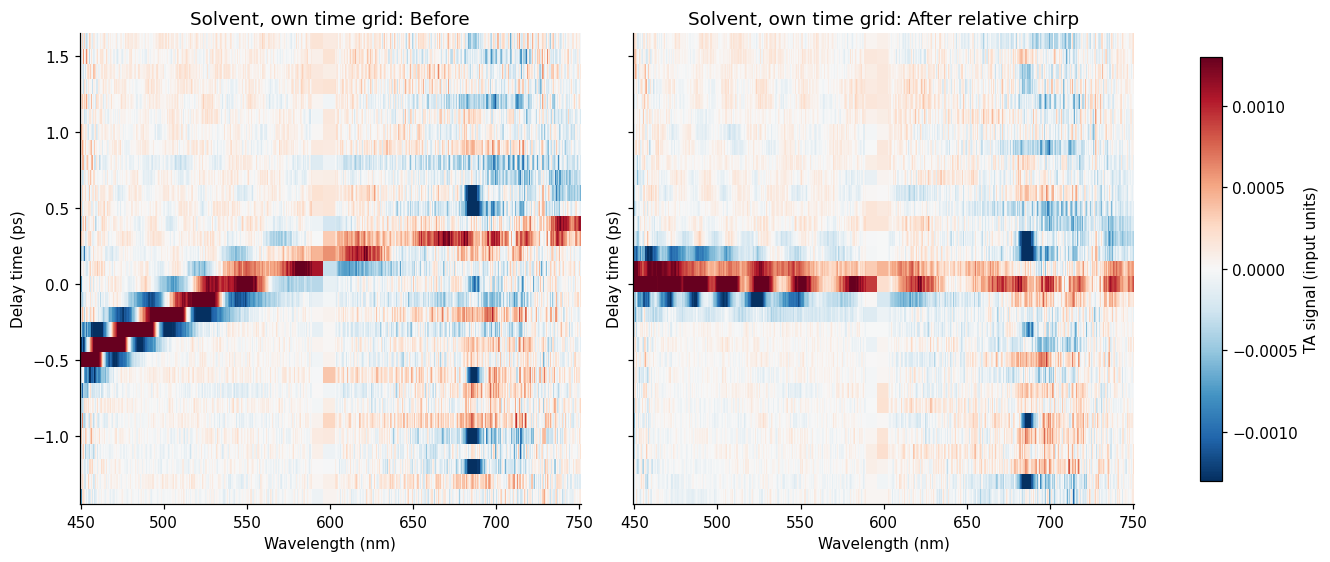

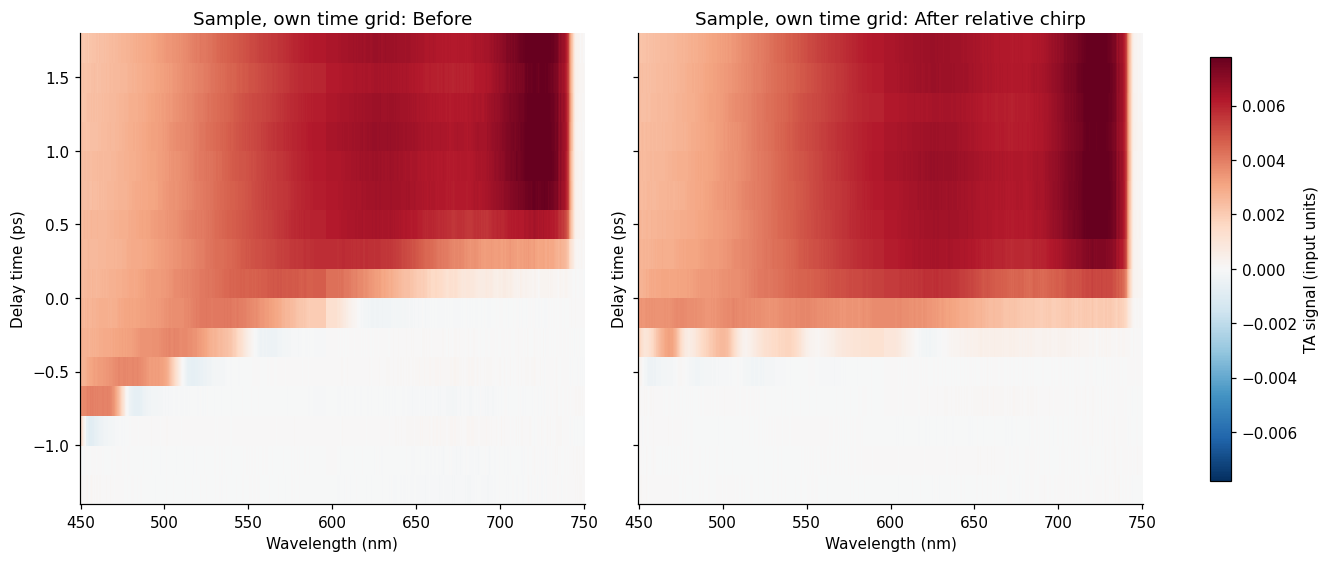

In [12]:
fig_chirp, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
ax = axes[0]
ax.scatter(bin_wavelength_nm[~fit_accepted], bin_diagnostics.peak_time_ps[~fit_accepted],
           s=15, color='0.7', marker='x', label='Excluded fits')
ax.scatter(bin_wavelength_nm[fit_accepted], bin_diagnostics.peak_time_ps[fit_accepted],
           s=20, color='#146c8e', label='Accepted solvent peak anchors')
ax.plot(wavelength_nm, raw_chirp_curve_ps, color='#c6652b', lw=2, label='Robust cubic')
lo, hi = np.percentile(raw_chirp_curve_ps, [0, 100])
ax.set(xlabel='Wavelength (nm)', ylabel='Solvent calibration peak (ps)',
       title='Solvent-only chirp calibration', ylim=(lo-.12, hi+.12))
ax.legend(fontsize=8)
axes[1].plot(wavelength_nm, applied_delay_curve_ps, color='#146c8e', lw=2)
axes[1].axhline(0, color='0.5', lw=.8, ls=':')
axes[1].axvline(reference_wavelength_nm, color='0.5', lw=.8, ls=':')
axes[1].set(xlabel='Wavelength (nm)', ylabel='Delay removed from sample (ps)',
            title=f'{TIME_REFERENCE.capitalize()} correction; reference {reference_wavelength_nm:.2f} nm')
fig_chirp.savefig(OUTPUT_DIR/'01_chirp_curve.png')
plt.show()

if SHOW_DIAGNOSTIC_PLOTS:
    fig_fits, axes = plt.subplots(2, 4, figsize=(14, 7), layout='constrained')
    for ax, target in zip(axes.ravel(), np.linspace(wavelength_nm.min()+6, wavelength_nm.max()-15, 8)):
        i = int(np.argmin(abs(bin_wavelength_nm-target)))
        fit = fit_details[i]
        ax.plot(fit['t'], fit['observed'], 'o', ms=3.5, color='0.15', label='Measured solvent')
        if fit['success']:
            dense = np.linspace(fit['t'][0], fit['t'][-1], 1000)
            p = fit['parameters']
            prediction = artifact_design(dense, p[5], np.exp(p[6]), fit['origin'])@p[:5]
            ax.plot(dense, prediction, color='#146c8e', label='G + first + second derivative')
            ax.axvline(fit['peak_time_ps'], color='#c6652b', ls=':', label='Calibration peak')
        ax.set(xlim=(-1.15, 1.05), title=f'{bin_wavelength_nm[i]:.1f} nm | '+('accepted' if fit_accepted[i] else 'excluded'),
               xlabel='Solvent delay (ps)', ylabel='TA signal (input units)')
    axes[0, 0].legend(fontsize=7)
    fig_fits.savefig(OUTPUT_DIR/'02_solvent_fit_traces.png')
    plt.show()

def comparison_maps(time, before, after, title_prefix, filename, trace_level):
    mask = window_mask(time, DISPLAY_TIME_WINDOW_PS)
    finite = np.r_[before[:, mask].ravel(), after[:, mask].ravel()]
    finite = finite[np.isfinite(finite)]
    limit = max(float(np.percentile(abs(finite), 98.5)), 1e-12)
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, layout='constrained')
    after_label = ('After relative chirp' if trace_level == 'relative' else
                   'After solvent subtraction' if trace_level == 'subtraction' else 'After chirp')
    for ax, z, label in zip(axes, [before, after], ['Before', after_label]):
        mesh = ax.pcolormesh(wavelength_nm, time[mask], z[:, mask].T,
                             cmap='RdBu_r', norm=norm, shading='auto')
        ax.set(xlabel='Wavelength (nm)', ylabel='Delay time (ps)', title=f'{title_prefix}: {label}')
    fig.colorbar(mesh, ax=axes, label='TA signal (input units)', shrink=.9)
    fig.savefig(OUTPUT_DIR/filename)
    plt.show()
comparison_maps(solvent_raw.time_ps, solvent_bc, solvent_chirp_corrected,
                'Solvent, own time grid', '03_solvent_before_after.png', 'relative')
comparison_maps(sample_raw.time_ps, sample_bc, sample_chirp_corrected,
                'Sample, own time grid', '04_sample_before_after.png', TIME_REFERENCE)
if artifact_corrected_sample is not None:
    comparison_maps(sample_raw.time_ps, sample_chirp_corrected, artifact_corrected_sample,
                    'Sample with optional subtraction', '05_optional_subtraction.png', 'subtraction')

## 导出与限制

- `chirp_corrected_sample_full_grid.csv`：保留全部 sample 时间坐标，测量范围外为 NaN。
- `chirp_corrected_sample_common_support.csv`：裁去任何波长缺失的时间列，可用于要求矩形有限值矩阵的后续分析。
- `chirp_corrected_solvent_own_grid.csv`：solvent 自己网格上的相对校正结果，不能视为已经与 sample 整体对齐。
- `chirp_curve_and_diagnostics.csv`：明确列出 solvent 校准曲线、实际移除的延迟、离可信锚点距离和边缘外推标记。
- `wavelength_bin_diagnostics.csv`：完整保留各 bin 的接受/排除原因、拟合中心、校准峰、采样边界和过冲诊断。

低 SNR 波段的曲线由相邻可信波段约束。平滑曲线不会恢复未测得的信息。
0.1 ps / 0.2 ps 的时间步长分别来自本示例的 solvent / sample；拟合或插值的更多小数位不等于更高的实验时间分辨率。

In [13]:
pixel_bin = np.empty(len(wavelength_nm), dtype=int)
for i, members in enumerate(bin_members):
    pixel_bin[members] = i
chirp_diagnostics = pd.DataFrame(dict(
    wavelength_nm=wavelength_nm, solvent_calibration_peak_ps=raw_chirp_curve_ps,
    applied_sample_delay_ps=applied_delay_curve_ps,
    source_bin=pixel_bin, source_bin_accepted=fit_accepted[pixel_bin],
    nearest_accepted_anchor_distance_nm=nearest_anchor_distance_nm,
    outside_anchor_range=chirp_extrapolated,
    solvent_baseline_removed=solvent_baseline, sample_baseline_removed=sample_baseline,
))
bin_diagnostics.to_csv(OUTPUT_DIR/'wavelength_bin_diagnostics.csv', index=False)
chirp_diagnostics.to_csv(OUTPUT_DIR/'chirp_curve_and_diagnostics.csv', index=False)
export_matrix('chirp_corrected_sample_full_grid.csv', corrected_time_ps, sample_chirp_corrected)
export_matrix('chirp_corrected_sample_common_support.csv', corrected_time_ps[common_support],
              sample_chirp_corrected[:, common_support])
export_matrix('chirp_corrected_solvent_own_grid.csv', solvent_raw.time_ps, solvent_chirp_corrected)
if artifact_corrected_sample is not None:
    export_matrix('artifact_corrected_sample.csv', corrected_time_ps, artifact_corrected_sample)
    export_matrix('scaled_solvent_term_used.csv', corrected_time_ps, scaled_solvent_term)

def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

run_summary = dict(
    created_utc=datetime.now(timezone.utc).isoformat(),
    inputs={label: dict(filename=path.name, sha256=file_sha256(path))
            for label, path in [('sample', SAMPLE_CSV), ('solvent', SOLVENT_CSV)]},
    coordinate_contract='same wavelengths; independent time arrays; matrices [wavelength,time]',
    calibration_marker='specified-polarity main peak of G+G1+G2 pulse, not Gaussian center',
    time_reference=TIME_REFERENCE, reference_wavelength_nm=reference_wavelength_nm,
    manual_solvent_shift_ps=MANUAL_SOLVENT_SHIFT_PS, automatic_alignment_used=False,
    solvent_subtraction_enabled=ENABLE_SOLVENT_SUBTRACTION, subtraction_scale=subtraction_scale,
    sample_time_points=int(len(corrected_time_ps)), solvent_time_points=int(len(solvent_raw.time_ps)),
    common_support_time_points=int(common_support.sum()), accepted_bins=int(fit_accepted.sum()),
    total_bins=int(len(bin_members)), median_bin_rmse=float(bin_diagnostics.rmse.median()),
    median_accepted_anchor_residual_ps=chirp_model['median_abs_residual_ps'],
    largest_anchor_gap_nm=chirp_model['max_anchor_gap_nm'],
    extrapolated_edge_wavelengths=int(chirp_extrapolated.sum()),
    polynomial={k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in chirp_model.items()},
    parameters=dict(solvent_baseline_ps=SOLVENT_BASELINE_WINDOW_PS,
        sample_baseline_ps=SAMPLE_BASELINE_WINDOW_PS, fit_window_ps=ARTIFACT_FIT_WINDOW_PS,
        wavelength_bin_size=WAVELENGTH_BIN_SIZE, artifact_polarity=ARTIFACT_POLARITY,
        n_starts=N_FIT_STARTS, sigma_min_solvent_steps=SIGMA_MIN_IN_SOLVENT_STEPS,
        sigma_upper_ps=SIGMA_UPPER_PS, min_snr=MIN_ARTIFACT_SNR,
        max_rmse_over_noise=MAX_FIT_RMSE_OVER_NOISE, max_peak_spread_ps=MAX_NEAR_OPTIMAL_PEAK_SPREAD_PS,
        near_cost_fraction=NEAR_OPTIMAL_COST_FRACTION, max_overshoot=MAX_MODEL_OVERSHOOT_RATIO,
        chirp_robust_scale_ps=CHIRP_ROBUST_SCALE_PS),
    packages=dict(numpy=np.__version__, scipy=scipy.__version__, pandas=pd.__version__, matplotlib=matplotlib.__version__),
    reference='https://doi.org/10.1007/s003400100750',
    limitations=['Calibration peak is an operational timing marker, not an independent absolute time-zero measurement.',
                 'Parameter spread across starts is not a confidence interval.',
                 'Interpolation adds no experimental time resolution.',
                 'Weak solvent bands remain weak; inspect anchor-distance flags.'],
)
(OUTPUT_DIR/'run_summary.json').write_text(json.dumps(run_summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved results to {OUTPUT_DIR.resolve()}')
display(chirp_diagnostics.iloc[[0, reference_index, -1]][['wavelength_nm', 'solvent_calibration_peak_ps', 'applied_sample_delay_ps']])

Saved results to /workspace/scratch/8f08057e5983/output/TA_chirp_checked/ta_chirp_checked_outputs


,wavelength_nm,solvent_calibration_peak_ps,applied_sample_delay_ps
0,449.764465,-0.520121,-0.559513
172,550.126343,0.039391,0.000000
488,750.345581,0.386097,0.346706
